# FX Pairs - Strategy Analysis

This notebook converts the FX pairs backtest registry into a per-case-study
strategy assessment. Every metric is reported with its block-bootstrap 95%
confidence interval, every comparison goes through
`backtest_paired_metrics`, and the holdout closure uses paired rather
than point-difference reasoning. Cross-case-study comparison is reserved
for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics (Sharpe ± CI, PSR, DSR) from the
  registry rather than transcribing point estimates.
- Trace a rank-1 lineage through pipeline stages with paired-bootstrap
  stage-transition deltas.
- Use the equal-weight universe benchmark for both validation and holdout
  diagnostics.
- Distinguish a wide-CI null result from a sign-flip; both forbid
  verdict language.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `13_backtest`; the
case-study registry (`case_studies/fx_pairs/run_log/registry.db`).

**Scope**: registry-read only - no training, no re-backtesting, no
registry writes. The `backtest_paired_metrics` table was populated by
`20_strategy_synthesis/01_aggregate_synthesis.py`.

In [1]:
"""FX Pairs - Strategy Analysis."""

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_concentration_curve,
    plot_sharpe_waterfall,
)
from utils.paths import display_path, get_case_study_dir, get_output_dir
from utils.style import COLORS

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY = "fx_pairs"
PERIODS_PER_YEAR = 252  # FX calendar
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)


def _read_registry(query: str, parameters: tuple = ()) -> pl.DataFrame:
    """Read the frozen registry without creating SQLite side files."""
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro&immutable=1", uri=True)
    connection.row_factory = sqlite3.Row
    try:
        rows = connection.execute(query, parameters).fetchall()
        return pl.DataFrame([dict(row) for row in rows], infer_schema_length=None)
    finally:
        connection.close()


def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "-"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [-, -]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"

BacktestExplorer('fx_pairs', 1415 runs: allocation=814, cost_sensitivity=33, holdout=1, risk_overlay=59, signal=508)


## §1 Handoff from model analysis

The strategy phase inherits a single rank-1 model from
`16_model_analysis.py` §8. That model's daily-pooled IC and HAC-adjusted
95% CI define the upstream prior on backtest stability - a wide IC CI
tells us to expect a wide Sharpe CI even before any strategy noise.

In [4]:
# Rank-1 selection pools validation backtests across the holdout-eligible
# stages (signal / allocation / risk_overlay) and dedupes by prediction_hash,
# keeping the highest-Sharpe strategy_spec per trained model. Mirrors
# `20_strategy_synthesis/holdout.py::HOLDOUT_SELECTION_STAGES`.
_HOLDOUT_STAGES = ("signal", "allocation", "risk_overlay")
top_signal = (
    pl.concat(
        [explorer.best(stage=s, top_n=2000) for s in _HOLDOUT_STAGES],
        how="diagonal_relaxed",
    )
    .filter(pl.col("family") != "benchmark")
    .sort("sharpe", descending=True)
    .unique(subset=["prediction_hash"], keep="first", maintain_order=True)
    .head(1)
)
TOP_HASH = top_signal.row(0, named=True)["backtest_hash"]
TOP_PHASH = top_signal.row(0, named=True)["prediction_hash"]
RANK1_FAMILY = top_signal.row(0, named=True)["family"]
RANK1_CONFIG = top_signal.row(0, named=True)["config_name"]
# The strategy-stage rank-1 may sit on a variant label rather than the
# setup.yaml primary. Carry the rank-1's own label through every
# downstream lookup (benchmark, rebalance_step, narrative_facts).
PRIMARY_LABEL = top_signal.row(0, named=True)["label"]

# Pull the prediction-side IC with HAC CI from prediction_metrics.
_ic = _read_registry(
    """
    SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac,
           ic_n_days, ic_hac_lag, ic_pct_positive
    FROM prediction_metrics
    WHERE prediction_hash = ?
    """,
    (TOP_PHASH,),
).row(0, named=True)
ic_mean = _ic["ic_mean_daily"]
ic_lo = _ic["ic_ci_lo"]
ic_hi = _ic["ic_ci_hi"]
ic_t = _ic["ic_t_hac"]
ic_p = _ic["ic_p_hac"]
ic_ndays = _ic["ic_n_days"]
ic_lag = _ic["ic_hac_lag"]
ic_pct = _ic["ic_pct_positive"]

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={PRIMARY_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print()
print("Daily-pooled IC (validation):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=linear, config=ridge_a100.0, label=fwd_ret_21d
        prediction_hash=2855922eab98, backtest_hash=4856002ebf10

Daily-pooled IC (validation):
  IC = 0.0124 [-0.0360, 0.0608]  (HAC, lag=20)
  t_HAC = 0.502, p_HAC = 0.615
  n_days = 2064, pct_positive = 51.9%
  CI status: straddles_zero


Daily-pooled IC at the rank-1 prediction set is small and its HAC-adjusted
CI straddles zero, so the prior on validation Sharpe is correspondingly
weak: the model has no statistically distinguishable linear relationship
with the rank-1 forward-return horizon. Any Sharpe CI reported in §3 is
expected to be wide; a point estimate close to zero is the prior, not a
surprise. Selection-adjusted views (DSR, PBO) in §3 will compound this
across the multi-stage sweep that produced the rank-1 selection.

**Kill conditions** are not encoded in `setup.yaml` for fx_pairs. The
notebook evaluates two universal gates in §9: (i) the selected strategy's
Sharpe CI lower bound ≥ 0, and (ii) the holdout strategy-vs-EW paired CI does
not exclude zero on the negative side. Both are reported as
pass / partial / fail without verdict labels.

## §2 Search context, family comparison, and lineage waterfall

The signal stage of the locked sweep produced several hundred validation
backtests spanning four model families (linear / gbm / tabular_dl /
deep_learning) across three label horizons (1d / 5d / 21d). The rank-1
row emerges as one realization of that search; what matters next is its
context - where the rank-1 sits in the family-level distribution and how
its performance evolves through the pipeline stages.

In [5]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Signal-stage search context:")
print(search_table)

Signal-stage search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total signal backtests      ┆ 508    │
│ Mean Sharpe                 ┆ -0.994 │
│ Median Sharpe               ┆ -0.599 │
│ P90 Sharpe                  ┆ -0.136 │
│ % positive Sharpe           ┆ 0.0%   │
│ Top-by-Sharpe in this sweep ┆ -0.004 │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [6]:
# Family comparison reads sharpe_ci95 from backtest_metrics directly so
# the forest plot can render proper error bars rather than median-only points.
_famdf = _read_registry(
    """
    SELECT t.family, bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi
    FROM backtest_metrics bm
    JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
    JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
    JOIN training_runs t ON p.training_hash = t.training_hash
    WHERE b.stage = 'signal'
      AND p.split = 'validation'
      AND bm.sharpe IS NOT NULL
      AND (bm.num_trades IS NULL OR bm.num_trades > 0)
    """
)

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level signal-stage Sharpe summary:")
print(family_summary)

Family-level signal-stage Sharpe summary:
shape: (4, 7)
┌───────────────┬─────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family        ┆ n   ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---           ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞═══════════════╪═════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ gbm           ┆ 220 ┆ -0.505347     ┆ -2.749817  ┆ -0.342733  ┆ -0.070025  ┆ 0.0          │
│ linear        ┆ 256 ┆ -0.598319     ┆ -0.985594  ┆ -0.258175  ┆ -0.004311  ┆ 0.0          │
│ deep_learning ┆ 20  ┆ -1.393378     ┆ -1.960873  ┆ -0.814613  ┆ -0.667517  ┆ 0.0          │
│ tabular_dl    ┆ 12  ┆ -2.394593     ┆ -2.585601  ┆ -2.194018  ┆ -2.04603   ┆ 0.0          │
└───────────────┴─────┴───────────────┴────────────┴────────────┴────────────┴──────────────┘


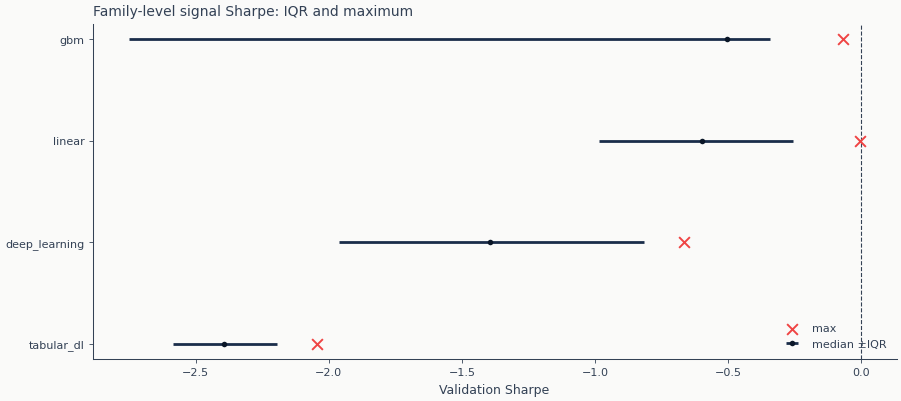

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color=COLORS["negative"], s=60, label="max", zorder=5)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Family-level signal Sharpe: IQR and maximum")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.show()

Family-level distributions cluster around zero; no family achieves a
median Sharpe meaningfully above zero, and the maximum-by-family points
are sparse outliers rather than evidence of a stable advantage. This is
the search-cost setting selection-adjustment is built for.

In [8]:
# Lineage with CI bars. champion_lineage gives stage hashes; we re-pull
# Sharpe CIs from backtest_metrics for each stage to render error bars.
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for rank-1 prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

# Surface missing stages without recomputing them.
missing_stages = [s for s in ("cost_sensitivity", "risk_overlay") if s not in lineage]
if missing_stages:
    print()
    print(f"Stage transitions not run for this prediction: {missing_stages}")

Lineage stages present for rank-1 prediction:
  signal: hash=db64dfca5cba, Sharpe=-0.085 [-0.745, 0.666]
  allocation: hash=e1ac43ef7f7a, Sharpe=0.037 [-0.643, 0.777]
  cost_sensitivity: hash=8907a1cd78cf, Sharpe=0.324 [-0.345, 1.042]
  risk_overlay: hash=4856002ebf10, Sharpe=0.048 [-0.560, 0.726]


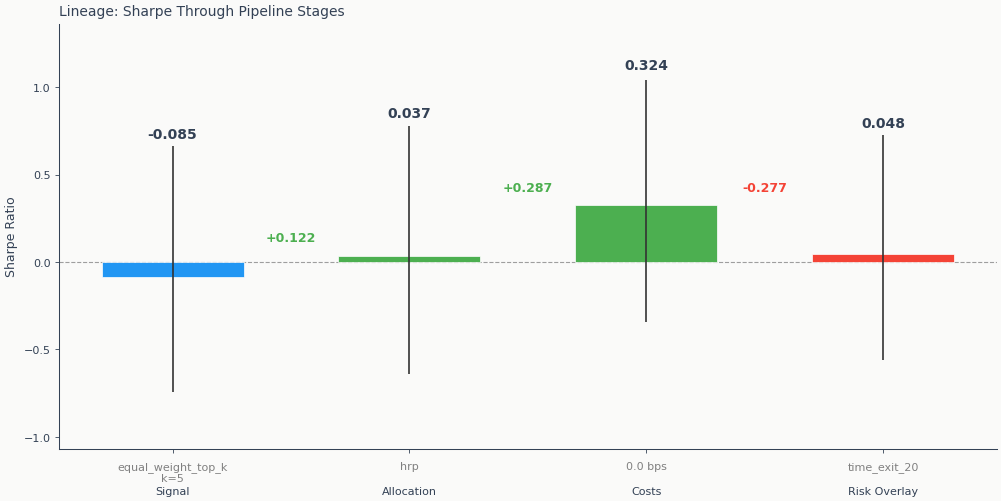

In [9]:
fig = plot_sharpe_waterfall(lineage, ci_lo=ci_lo, ci_hi=ci_hi)
fig.axes[0].tick_params(axis="x", pad=24)
fig.show()

In [10]:
# Stage-transition deltas come from the paired-metrics table. The cost leader
# is the zero-cost endpoint, so the final pair restores configured costs while
# adding the risk overlay; it is not a risk-only contrast.
ALLOC_HASH = lineage.get("allocation", {}).get("backtest_hash")
COST_HASH = lineage.get("cost_sensitivity", {}).get("backtest_hash")
RISK_HASH = lineage.get("risk_overlay", {}).get("backtest_hash")
transitions = [
    ("Allocation vs equal-weight baseline", ALLOC_HASH, "signal_leader"),
    ("Zero-cost endpoint vs configured-cost allocation", COST_HASH, "allocation_leader"),
    (
        "Risk overlay at configured costs vs zero-cost endpoint",
        RISK_HASH,
        "cost_sensitivity_leader",
    ),
]
for label, challenger_hash, benchmark_kind in transitions:
    if challenger_hash is None:
        continue
    pair = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=challenger_hash,
        benchmark_kind=benchmark_kind,
    )
    if not pair.is_empty():
        r = pair.row(0, named=True)
        print(label)
        print(
            f"  sharpe_diff = "
            f"{_fmt_ci(r['sharpe_diff'], r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}"
        )
        print(f"  p_value = {r['p_value']:.3f}")
        print(f"  prob_challenger_wins = {r['prob_challenger_wins']:.3f}")
        print(f"  CI status: {ci_status(r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}")
        print()

Allocation vs equal-weight baseline
  sharpe_diff = 0.120 [-0.131, 0.361]
  p_value = 0.342
  prob_challenger_wins = 0.823
  CI status: straddles_zero

Zero-cost endpoint vs configured-cost allocation
  sharpe_diff = 0.282 [0.242, 0.329]
  p_value = 0.000
  prob_challenger_wins = 1.000
  CI status: excludes_zero_strong

Risk overlay at configured costs vs zero-cost endpoint
  sharpe_diff = -0.272 [-0.658, 0.127]
  p_value = 0.171
  prob_challenger_wins = 0.095
  CI status: straddles_zero



The selected prediction is present at every stage. HRP raises Sharpe from
-0.085 to 0.037, but the paired interval spans zero. Removing 7 bps of
configured costs raises Sharpe to 0.324 with a paired interval above zero;
this is a friction contrast, not evidence of positive standalone Sharpe.
The final registered pair combines restoring those costs with adding the
20-day time exit. Section 4 therefore reports the overlay's drawdown change
descriptively against the configured-cost allocation.

Allocation: best Sharpe by top_k:
shape: (2, 4)
┌───────┬────────────────┬───────────┬──────────────┐
│ top_k ┆ allocator      ┆ sharpe    ┆ max_drawdown │
│ ---   ┆ ---            ┆ ---       ┆ ---          │
│ i64   ┆ str            ┆ f64       ┆ f64          │
╞═══════╪════════════════╪═══════════╪══════════════╡
│ 5     ┆ hrp            ┆ 0.037126  ┆ -0.296518    │
│ 10    ┆ score_weighted ┆ -0.290026 ┆ -0.344408    │
└───────┴────────────────┴───────────┴──────────────┘


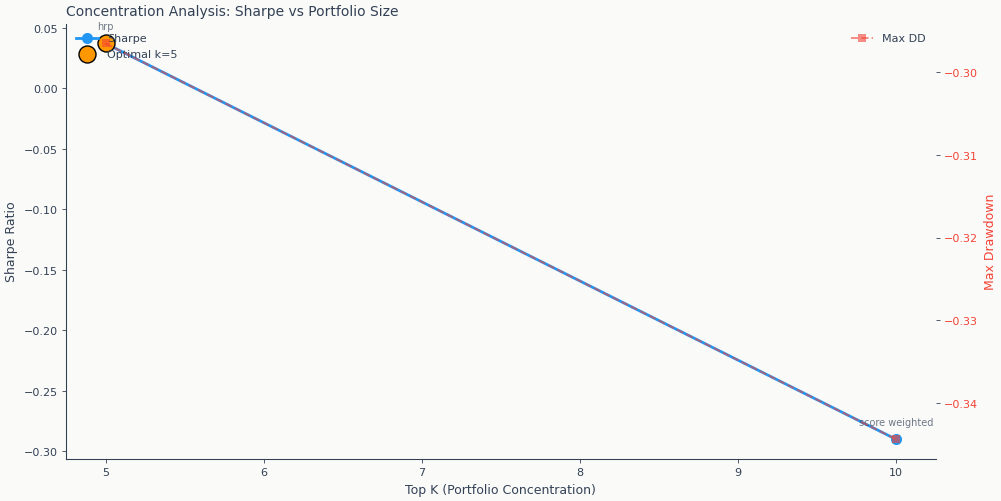

In [11]:
conc_df = explorer.concentration_curve(TOP_PHASH)
if not conc_df.is_empty():
    fig = plot_concentration_curve(conc_df)
    fig.show()
    best_per_k = conc_df.sort("sharpe", descending=True).group_by("top_k").first().sort("top_k")
    print("Allocation: best Sharpe by top_k:")
    print(best_per_k.select("top_k", "allocator", "sharpe", "max_drawdown"))
else:
    print("No concentration data - allocation stage absent for this prediction.")

With 20 G10 pairs and roughly three independent currency blocks
(USD, EUR, JPY) driving the cross-section, concentration is structurally
constrained: small top_k captures the strongest scores but concentrates
block risk; larger top_k dilutes a thin signal. The curve does not
reveal a top_k that pushes Sharpe above zero.

## §3 Headline performance with uncertainty

The rank-1 specification is the validation-window backtest selected across
the eligible signal, allocation, and risk-overlay stages. Every metric is reported with its
block-bootstrap 95% CI from `backtest_metrics`; the equity overlay shows
the cumulative trajectory against the equal-weight universe benchmark.

In [12]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

# When the spine's rank-1 (max-Sharpe across signal+allocation+risk_overlay)
# sits at a stage that `cohort_metrics` does not materialize (risk_overlay),
# or when the spine rank-1 is a sibling at the same canonical spec that
# differs from the cohort leader, `load_backtest_metrics` returns NULL
# selection-bias fields. Fall back to the closest family cohort row at
# (allocation, primary label, rank-1 family) for DSR_ER/PBO/min_trl - these
# are properties of the cohort, not of the individual sibling. ER is the
# maintainer-recommended default per memory/UNCERTAINTY_ARCHITECTURE.md.
_cohort_leader_hash = None
_cohort_leader_sharpe = None
_cohort_stage = None
if full.get("dsr") is None:
    _stage_for_cohort = _read_registry(
        "SELECT stage FROM backtest_runs WHERE backtest_hash = ?",
        (TOP_HASH,),
    )["stage"][0]
    # Try the spine rank-1's exact stage first; fall back to allocation if
    # cohort_metrics didn't materialize a row for risk_overlay.
    for _try_stage in (_stage_for_cohort, "allocation", "signal"):
        _cohort = _read_registry(
            """
            SELECT dsr_er, dsr_er_pvalue, expected_max_sharpe_er,
                   min_trl_periods_er, pbo, pbo_n_combinations, pbo_n_folds,
                   k_variants, leader_hash, leader_sharpe
            FROM cohort_metrics
            WHERE cohort_type='family' AND stage=? AND label=? AND family=?
            """,
            (_try_stage, PRIMARY_LABEL, RANK1_FAMILY),
        )
        if not _cohort.is_empty():
            full = dict(full)  # mutate
            cohort_row = _cohort.row(0, named=True)
            full["dsr"] = cohort_row["dsr_er"]
            full["dsr_pvalue"] = cohort_row["dsr_er_pvalue"]
            full["expected_max_sharpe"] = cohort_row["expected_max_sharpe_er"]
            full["min_trl_periods"] = cohort_row["min_trl_periods_er"]
            full["pbo"] = cohort_row["pbo"]
            full["pbo_n_combinations"] = cohort_row["pbo_n_combinations"]
            full["pbo_n_folds"] = cohort_row["pbo_n_folds"]
            full["k_variants"] = cohort_row["k_variants"]
            _cohort_leader_hash = cohort_row["leader_hash"]
            _cohort_leader_sharpe = cohort_row["leader_sharpe"]
            _cohort_stage = _try_stage
            print(
                f"  cohort fallback: family cohort `{_try_stage}/"
                f"{PRIMARY_LABEL}/{RANK1_FAMILY}` "
                f"leader_hash={_cohort_leader_hash} leader_sharpe="
                f"{_cohort_leader_sharpe:.3f} (spine rank-1 sibling at "
                f"`{_stage_for_cohort}` differs by "
                f"{full['sharpe'] - _cohort_leader_sharpe:+.3f})."
            )
            break

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": PRIMARY_LABEL,
    "signal_method": lineage["signal"].get("signal_method"),
    "top_k": lineage["signal"].get("top_k"),
    "allocation": lineage.get("allocation", {}).get("allocator"),
    "rebalance_step_days": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    "cost_assumption": "7 bps per traded leg; zero-cost sensitivity in §5",
    "risk_overlay": lineage.get("risk_overlay", {}).get("risk_name") or "none at this lineage",
    "validation_window_periods": int(full["n_periods"]) if full["n_periods"] is not None else None,
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full["avg_turnover"],
    "bootstrap_block_length": int(full["bootstrap_block_length"])
    if full["bootstrap_block_length"] is not None
    else None,
    "bootstrap_n": int(full["bootstrap_n"]) if full["bootstrap_n"] is not None else None,
}
print("Rank-1 specification (risk-overlay stage, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

# Audit: bootstrap_block_length should match the label's rebalance_step.
_block = int(full["bootstrap_block_length"])
_rstep = setup["labels"]["rebalance_step"][PRIMARY_LABEL]
if _block != _rstep:
    print(
        f"  audit: bootstrap_block_length={_block} ≠ rebalance_step={_rstep} "
        "- rebalance overlap could under-cover the CI."
    )

Rank-1 specification (risk-overlay stage, validation window):
  case_study: fx_pairs
  family: linear
  config_name: ridge_a100.0
  label: fwd_ret_21d
  signal_method: equal_weight_top_k
  top_k: 5
  allocation: hrp
  rebalance_step_days: 21
  cost_assumption: 7 bps per traded leg; zero-cost sensitivity in §5
  risk_overlay: time_exit_20
  validation_window_periods: 2064
  num_trades: 637
  avg_turnover: 0.08746826349419266
  bootstrap_block_length: 12
  bootstrap_n: 1000
  audit: bootstrap_block_length=12 ≠ rebalance_step=21 - rebalance overlap could under-cover the CI.


In [13]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}


def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "-" if val is None else format(val, fmt)


sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])

headline = pl.DataFrame(
    [
        _row(
            "Sharpe",
            _fmt(full["sharpe"]),
            _fmt(full["sharpe_ci95_lo"]),
            _fmt(full["sharpe_ci95_hi"]),
            sharpe_status,
        ),
        _row(
            "Sortino",
            _fmt(full["sortino"]),
            _fmt(full["sortino_ci95_lo"]),
            _fmt(full["sortino_ci95_hi"]),
            sortino_status,
        ),
        _row(
            "Annualized return",
            _fmt(full["cagr"]),
            _fmt(full["ann_return_ci95_lo"]),
            _fmt(full["ann_return_ci95_hi"]),
            ann_status,
        ),
        _row(
            "Max drawdown",
            _fmt(full["max_drawdown"]),
            _fmt(full["max_dd_ci95_lo"]),
            _fmt(full["max_dd_ci95_hi"]),
            mdd_status,
        ),
        _row(
            "Calmar",
            _fmt(full["calmar"]),
            _fmt(full["calmar_ci95_lo"]),
            _fmt(full["calmar_ci95_hi"]),
            calmar_status,
        ),
        {
            "metric": "PSR p-value (H0: SR≤0)",
            "point": _fmt(full["psr_pvalue"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER (selection-adjusted)",
            "point": _fmt(full["dsr"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER p-value",
            "point": _fmt(full["dsr_pvalue"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": (
                f"Expected max Sharpe (k={int(full['k_variants'])})"
                if full["k_variants"] is not None
                else "Expected max Sharpe"
            ),
            "point": _fmt(full["expected_max_sharpe"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "PBO",
            "point": _fmt(full["pbo"], ".3f"),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
    ]
)
print("Rank-1 headline metrics with 95% CIs:")
print(headline)
if _cohort_leader_hash is not None:
    print(
        f"\nDSR_ER, expected-max-Sharpe, MinTRL_ER, PBO surfaced from "
        f"`cohort_metrics` (family cohort at stage `{_cohort_stage}`, "
        f"effective-rank K_eff trial count per `memory/"
        f"UNCERTAINTY_ARCHITECTURE.md`). These are cohort-level "
        f"properties; the rank-1 sibling's own selection-bias columns "
        f"on `backtest_metrics` are NULL post the cohort-metrics "
        f"migration."
    )

Rank-1 headline metrics with 95% CIs:
shape: (10, 5)
┌─────────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                      ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                         ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                         ┆ str     ┆ str     ┆ str     ┆ str                  │
╞═════════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                      ┆ 0.0476  ┆ -0.5602 ┆ 0.7257  ┆ straddles_zero       │
│ Sortino                     ┆ 0.0488  ┆ -0.5512 ┆ 0.7514  ┆ straddles_zero       │
│ Annualized return           ┆ 0.0011  ┆ -0.0342 ┆ 0.0392  ┆ straddles_zero       │
│ Max drawdown                ┆ -0.1673 ┆ -0.2938 ┆ -0.0741 ┆ excludes_zero_strong │
│ Calmar                      ┆ 0.0065  ┆ -0.1256 ┆ 0.4822  ┆ straddles_zero       │
│ PSR p-value (H0: SR≤0)      ┆ 0.4447  ┆ -       ┆ -       ┆ n/a                  │
│ DSR_ER (se

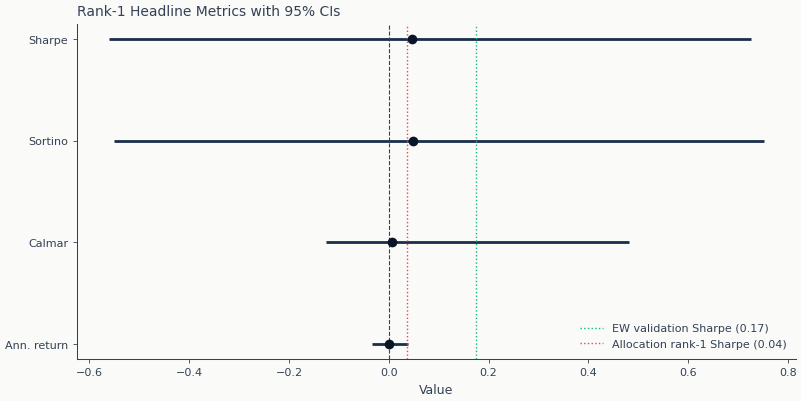

In [14]:
# Forest plot: rank-1 metrics with CI bars + reference lines
ew_val = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color=COLORS["positive"],
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
_alloc_sharpe = lineage.get("allocation", {}).get("sharpe")
if _alloc_sharpe is not None:
    ax.axvline(
        _alloc_sharpe,
        color=COLORS["negative"],
        linestyle=":",
        linewidth=1.0,
        label=f"Allocation rank-1 Sharpe ({_alloc_sharpe:.2f})",
    )
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("Rank-1 Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.show()

Validation overlay window: 2016-01-06 → 2023-12-29, n=2063


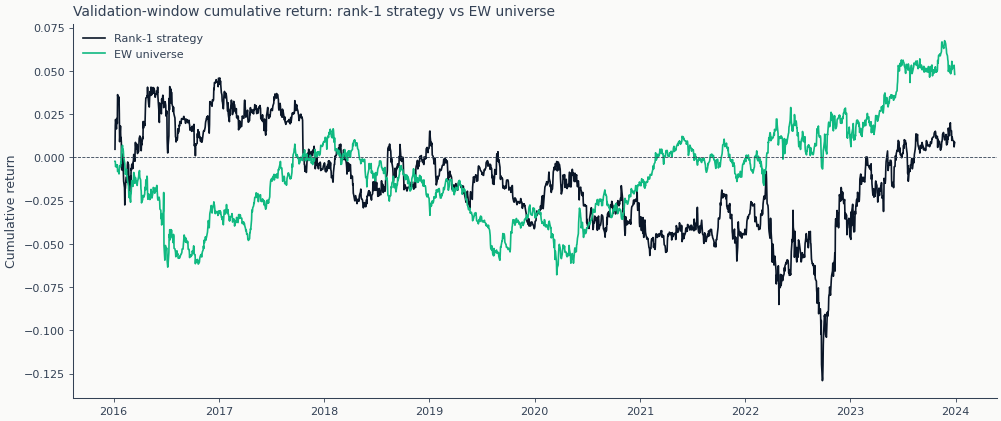

In [15]:
# Equity-curve overlay vs validation EW benchmark
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, PRIMARY_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(aligned["ts"], cum_strat, color=COLORS["blue"], linewidth=1.2, label="Rank-1 strategy")
ax.plot(
    aligned["ts"],
    cum_bench,
    color=COLORS["positive"],
    linewidth=1.2,
    label="EW universe",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: rank-1 strategy vs EW universe")
ax.legend(loc="best", frameon=False)
fig.show()

The Sharpe CI spans -0.560 to 0.726, the largest single
source of uncertainty about the rank-1's edge. Sortino, Calmar, and
annualized return CIs also straddle zero. The PSR p-value of 0.445 is
direct evidence that we cannot reject the null Sharpe ≤ 0 even before
selection adjustment. The linear risk-overlay cohort (k=20 variants)
carries DSR_ER -0.0068 with p-value 0.653 and expected maximum Sharpe
0.0098. The validation equal-weight benchmark logged Sharpe 0.175 over
the same window. The selected strategy trails it at the point estimate,
but the paired interval reported in §6 spans zero.

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired against
the validation EW benchmark. The drawdown panel surfaces the worst
episode and recovery; rolling Sharpe and rolling beta locate when the
strategy decoupled from the universe.

In [16]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
worst_dd = dd.top_drawdowns[0]
print(
    pl.DataFrame(
        [
            {
                "current_drawdown": dd.current_drawdown,
                "max_drawdown": dd.max_drawdown,
                "average_drawdown": dd.avg_drawdown,
                "worst_peak": worst_dd.peak_date,
                "worst_valley": worst_dd.valley_date,
                "recovered": worst_dd.recovery_date is not None,
                "max_duration_days": dd.max_duration_days,
            }
        ]
    )
)

Drawdown analysis (validation window):
shape: (1, 7)
┌──────────────┬──────────────┬──────────────┬────────────┬──────────────┬───────────┬─────────────┐
│ current_draw ┆ max_drawdown ┆ average_draw ┆ worst_peak ┆ worst_valley ┆ recovered ┆ max_duratio │
│ down         ┆ ---          ┆ down         ┆ ---        ┆ ---          ┆ ---       ┆ n_days      │
│ ---          ┆ f64          ┆ ---          ┆ date       ┆ date         ┆ bool      ┆ ---         │
│ f64          ┆              ┆ f64          ┆            ┆              ┆           ┆ i64         │
╞══════════════╪══════════════╪══════════════╪════════════╪══════════════╪═══════════╪═════════════╡
│ -0.035672    ┆ -0.167337    ┆ -0.058811    ┆ 2017-01-11 ┆ 2022-09-26   ┆ false     ┆ 1474        │
└──────────────┴──────────────┴──────────────┴────────────┴──────────────┴───────────┴─────────────┘


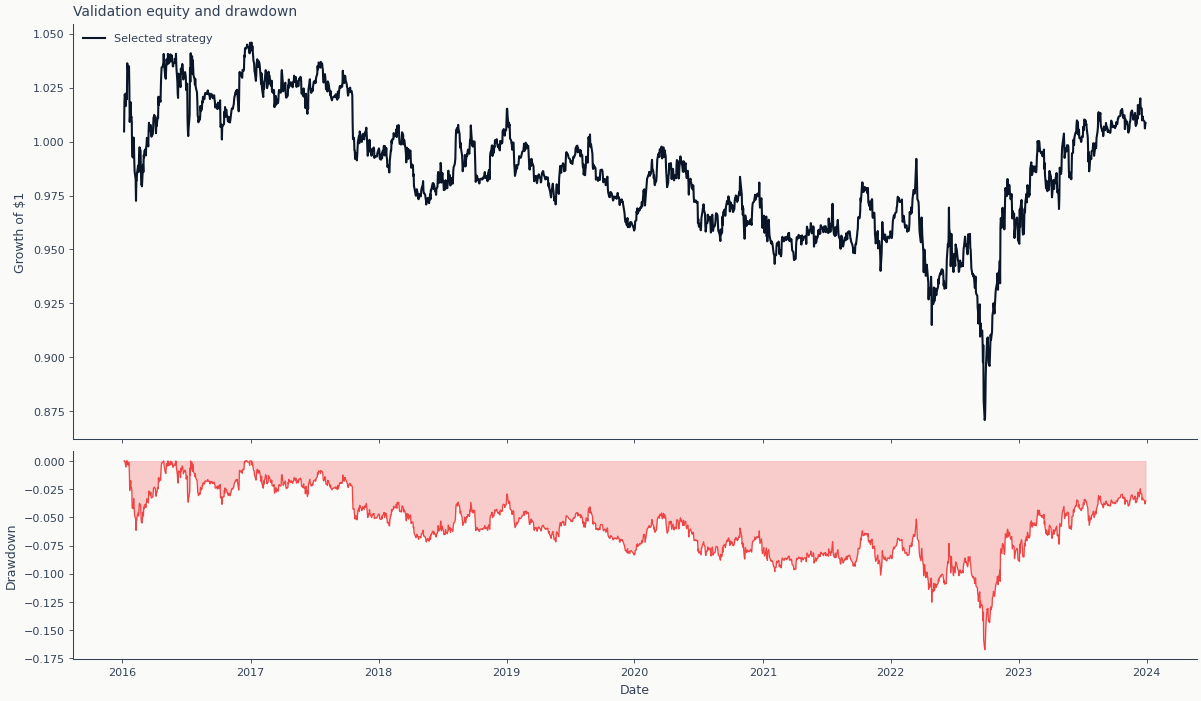

In [17]:
equity = np.cumprod(1 + strat_arr)
running_peak = np.maximum.accumulate(equity)
drawdown = equity / running_peak - 1
fig, (ax_equity, ax_drawdown) = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    height_ratios=[2, 1],
)
ax_equity.plot(ts_arr, equity, color=COLORS["blue"], linewidth=1.5, label="Selected strategy")
ax_equity.set_ylabel("Growth of $1")
ax_equity.set_title("Validation equity and drawdown")
ax_equity.legend(loc="upper left", frameon=False)
ax_drawdown.fill_between(ts_arr, drawdown, 0, color=COLORS["negative"], alpha=0.25)
ax_drawdown.plot(ts_arr, drawdown, color=COLORS["negative"], linewidth=0.9)
ax_drawdown.set_ylabel("Drawdown")
ax_drawdown.set_xlabel("Date")
fig.show()

In [18]:
# Rolling Sharpe + rolling beta
roll = pa.compute_rolling_metrics(windows=[126], metrics=["sharpe", "beta"])
rolling_sharpe = roll.sharpe[126].drop_nulls()
rolling_beta = roll.beta[126].drop_nulls()
print("126-day rolling diagnostics:")
print(
    pl.DataFrame(
        [
            {
                "metric": "Sharpe",
                "minimum": rolling_sharpe.min(),
                "median": rolling_sharpe.median(),
                "maximum": rolling_sharpe.max(),
                "latest": rolling_sharpe[-1],
            },
            {
                "metric": "Beta to EW",
                "minimum": rolling_beta.min(),
                "median": rolling_beta.median(),
                "maximum": rolling_beta.max(),
                "latest": rolling_beta[-1],
            },
        ]
    )
)

# Tail-risk read straight from registry (already computed and stored)
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

126-day rolling diagnostics:
shape: (2, 5)
┌────────────┬───────────┬───────────┬──────────┬───────────┐
│ metric     ┆ minimum   ┆ median    ┆ maximum  ┆ latest    │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str        ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞════════════╪═══════════╪═══════════╪══════════╪═══════════╡
│ Sharpe     ┆ -2.15084  ┆ -0.024887 ┆ 2.702713 ┆ 0.099491  │
│ Beta to EW ┆ -1.349796 ┆ -0.097951 ┆ 1.11663  ┆ -0.231576 │
└────────────┴───────────┴───────────┴──────────┴───────────┘

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.0579  │
│ VaR 95% (daily)   ┆ -0.0054 │
│ CVaR 95% (daily)  ┆ -0.0082 │
│ Tail ratio        ┆ 1.017   │
│ Skewness          ┆ 0.092   │
│ Kurtosis          ┆ 6.549   │
└───────────────────┴─────────┘


In [19]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown ({fold_df.height} folds):")
print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
print()
print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")

Per-fold breakdown (8 folds):
shape: (8, 4)
┌─────────┬───────────┬──────────────┬────────┐
│ fold_id ┆ sharpe    ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---       ┆ ---          ┆ ---    │
│ i64     ┆ f64       ┆ f64          ┆ f64    │
╞═════════╪═══════════╪══════════════╪════════╡
│ 0       ┆ 1.006895  ┆ -0.03151     ┆ 258.0  │
│ 1       ┆ -0.00272  ┆ -0.122074    ┆ 258.0  │
│ 2       ┆ -0.135746 ┆ -0.04187     ┆ 258.0  │
│ 3       ┆ 0.07774   ┆ -0.043879    ┆ 258.0  │
│ 4       ┆ -1.429824 ┆ -0.052364    ┆ 258.0  │
│ 5       ┆ 0.442598  ┆ -0.036559    ┆ 258.0  │
│ 6       ┆ -1.063163 ┆ -0.052216    ┆ 258.0  │
│ 7       ┆ 0.639753  ┆ -0.061553    ┆ 258.0  │
└─────────┴───────────┴──────────────┴────────┘

Fold Sharpe range: [-1.430, 1.007]
Fold Sharpe std:   0.827


Four folds are positive and four are negative, with Sharpe ranging from
-1.430 to 1.007. Tail kurtosis of 6.55 indicates fat-tailed returns. The
worst drawdown reaches -16.7% and does not recover inside the validation
window, so the smaller point drawdown from the time exit is not evidence
of stable risk control.

## §5 Friction budget & cost sensitivity

FX is the lowest-friction asset class in the book - major-pair spreads
of 1–3 bps, cross-pair spreads of 3–8 bps. The cost_sensitivity stage
of the locked sweep walked a synthetic per-leg cost grid; the curve
below shows how Sharpe responds to friction without re-running the
pipeline. The realistic-spread overlay marks the actual provider cost
range from `setup.yaml`.

In [20]:
COST_SQL = """
SELECT br.backtest_hash,
       (json_extract(br.spec_json, '$.backtest_config.commission.rate')
        + json_extract(br.spec_json, '$.backtest_config.slippage.rate')) * 10000.0 AS cost_bps,
       bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
       bm.max_drawdown, bm.num_trades
FROM backtest_runs br
JOIN backtest_metrics bm USING (backtest_hash)
JOIN prediction_sets ps USING (prediction_hash)
WHERE br.stage = 'cost_sensitivity'
  AND ps.split = 'validation'
  AND br.prediction_hash = ?
ORDER BY cost_bps
"""
cost_curve = _read_registry(COST_SQL, (TOP_PHASH,))
if cost_curve.height != 11:
    raise RuntimeError(f"Expected one 11-point cost curve, found {cost_curve.height} rows")
assert (cost_curve["sharpe"].diff().drop_nulls() < 0).all()

configured_cost = _read_registry(
    """
    SELECT (json_extract(spec_json, '$.backtest_config.commission.rate')
            + json_extract(spec_json, '$.backtest_config.slippage.rate')) * 10000.0 AS cost_bps
    FROM backtest_runs
    WHERE backtest_hash = ?
    """,
    (ALLOC_HASH,),
)["cost_bps"][0]
configured_row = cost_curve.filter((pl.col("cost_bps") - configured_cost).abs() < 1e-12).row(
    0, named=True
)
positive = cost_curve.filter(pl.col("sharpe") >= 0).tail(1).row(0, named=True)
negative = cost_curve.filter(pl.col("cost_bps") > positive["cost_bps"]).head(1).row(0, named=True)
breakeven_bps = positive["cost_bps"] + (
    positive["sharpe"]
    / (positive["sharpe"] - negative["sharpe"])
    * (negative["cost_bps"] - positive["cost_bps"])
)

print("Cost sensitivity for the selected 21-day Ridge/HRP lineage:")
print(cost_curve.select("cost_bps", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"))
print(f"Configured cost: {configured_cost:.1f} bps per traded leg")
print(f"Configured-cost Sharpe: {configured_row['sharpe']:.6f}")
print(f"Interpolated point-estimate breakeven: {breakeven_bps:.2f} bps per traded leg")

Cost sensitivity for the selected 21-day Ridge/HRP lineage:
shape: (11, 4)
┌──────────┬───────────┬────────────────┬────────────────┐
│ cost_bps ┆ sharpe    ┆ sharpe_ci95_lo ┆ sharpe_ci95_hi │
│ ---      ┆ ---       ┆ ---            ┆ ---            │
│ f64      ┆ f64       ┆ f64            ┆ f64            │
╞══════════╪═══════════╪════════════════╪════════════════╡
│ 0.0      ┆ 0.324366  ┆ -0.344673      ┆ 1.041798       │
│ 1.0      ┆ 0.282899  ┆ -0.391542      ┆ 1.003086       │
│ 2.0      ┆ 0.242116  ┆ -0.438723      ┆ 0.964806       │
│ 3.0      ┆ 0.201523  ┆ -0.482619      ┆ 0.927168       │
│ 5.0      ┆ 0.119861  ┆ -0.563619      ┆ 0.850353       │
│ …        ┆ …         ┆ …              ┆ …              │
│ 10.0     ┆ -0.085642 ┆ -0.756989      ┆ 0.652644       │
│ 15.0     ┆ -0.287552 ┆ -0.97173       ┆ 0.46011        │
│ 20.0     ┆ -0.484573 ┆ -1.171138      ┆ 0.270378       │
│ 30.0     ┆ -0.85855  ┆ -1.53673       ┆ -0.10409       │
│ 50.0     ┆ -1.496254 ┆ -2.134189      

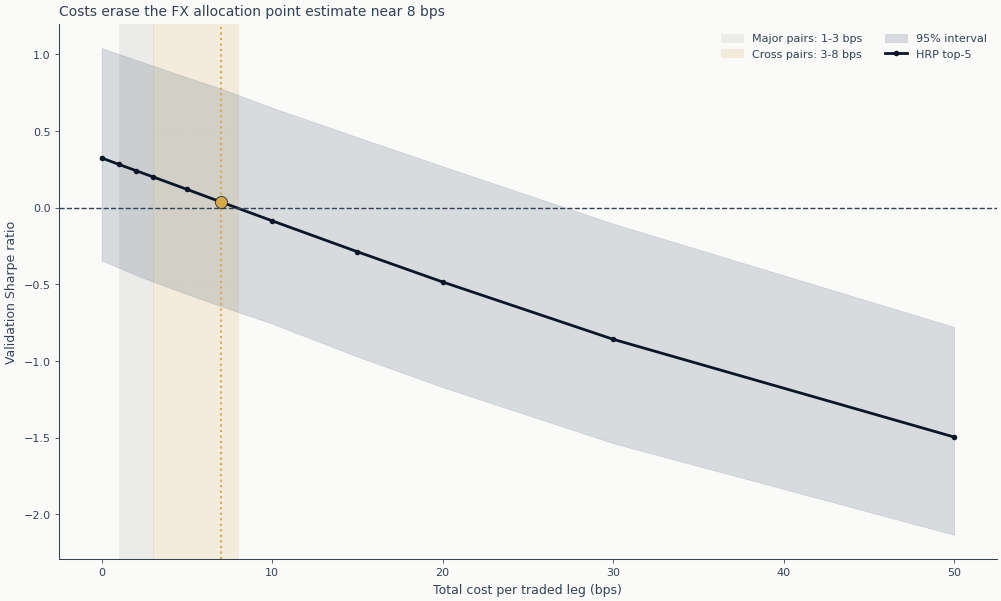

In [21]:
x = cost_curve["cost_bps"].to_numpy()
y = cost_curve["sharpe"].to_numpy()
lower = cost_curve["sharpe_ci95_lo"].to_numpy()
upper = cost_curve["sharpe_ci95_hi"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.axvspan(1, 3, color=COLORS["silver_muted"], alpha=0.8, label="Major pairs: 1-3 bps")
ax.axvspan(3, 8, color=COLORS["amber"], alpha=0.16, label="Cross pairs: 3-8 bps")
ax.fill_between(x, lower, upper, color=COLORS["slate"], alpha=0.15, label="95% interval")
ax.plot(x, y, color=COLORS["blue"], marker="o", linewidth=2, label="HRP top-5")
ax.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.axvline(configured_cost, color=COLORS["amber"], linewidth=1.5, linestyle=":")
ax.scatter(
    [configured_cost],
    [configured_row["sharpe"]],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=75,
    zorder=4,
)
ax.set_xlabel("Total cost per traded leg (bps)")
ax.set_ylabel("Validation Sharpe ratio")
ax.set_title("Costs erase the FX allocation point estimate near 8 bps")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="both", alpha=0.22)
fig.show()

This is the exact 21-day Ridge/HRP lineage, not a pool across label
horizons. Sharpe falls monotonically from 0.324 without costs to 0.037
at the configured 7 bps and -0.086 at 10 bps. The point estimate crosses
zero near 7.91 bps, at the upper edge of the declared cross-pair spread
band. Every standalone Sharpe interval spans zero, so execution quality
preserves a small point estimate but does not establish an edge.

## §6 Holdout closure with paired bootstrap

Two paired tests anchor the holdout read: (i) the holdout rank-1 versus
the validation rank-1 ("did Sharpe hold?"), and (ii) the holdout rank-1
versus the holdout-window equal-weight benchmark ("did the strategy
beat equal weight in the holdout?"). Numbers come from
`backtest_paired_metrics` - never from val_sharpe minus holdout_sharpe
arithmetic.

In [22]:
# Identify the holdout backtest matching val rank-1's complete strategy spec.
val_registry_row = _read_registry(
    """
    SELECT br.spec_json, ps.training_hash
    FROM backtest_runs br
    JOIN prediction_sets ps USING (prediction_hash)
    WHERE br.backtest_hash = ?
    """,
    (TOP_HASH,),
).row(0, named=True)
val_strategy = json.loads(val_registry_row["spec_json"]).get("strategy", {})
holdout_candidates = _read_registry(
    """
    SELECT br.backtest_hash, br.spec_json
    FROM backtest_runs br
    JOIN prediction_sets ps USING (prediction_hash)
    LEFT JOIN backtest_metrics bm USING (backtest_hash)
    WHERE ps.training_hash = ? AND ps.split = 'holdout'
    ORDER BY bm.sharpe DESC NULLS LAST
    """,
    (val_registry_row["training_hash"],),
)
matching_holdout = [
    row["backtest_hash"]
    for row in holdout_candidates.iter_rows(named=True)
    if json.loads(row["spec_json"]).get("strategy", {}) == val_strategy
]
if len(matching_holdout) != 1:
    raise RuntimeError(
        f"Expected one holdout backtest matching val rank-1 ({TOP_HASH}), "
        f"found {len(matching_holdout)}"
    )
HO_HASH = matching_holdout[0]

print(f"Validation rank-1 hash: {TOP_HASH}")
print(f"Holdout rank-1 hash:    {HO_HASH}")

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

Validation rank-1 hash: 4856002ebf10
Holdout rank-1 hash:    ea03d7a1cd49


In [23]:
# Paired val→ho decay table from load_paired_metrics
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    print(
        "[WARN] Missing val_rank1_self pair for fx_pairs - populator "
        "skipped (holdout has no trades or insufficient overlap with val "
        "lineage). Continuing with NaN val→holdout decay."
    )
    vh = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    vh = val_ho_pair.row(0, named=True)


def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h−v)": _fmt(diff, ".4f") if diff is not None else "-",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "-",
        "p-value": _fmt(p, ".4f") if p is not None else "-",
    }


val_ho_table = pl.DataFrame(
    [
        _diff_row(
            "Sharpe",
            val_full["sharpe"],
            ho_full["sharpe"],
            vh["sharpe_diff"],
            vh["sharpe_diff_ci95_lo"],
            vh["sharpe_diff_ci95_hi"],
            vh["p_value"],
        ),
        _diff_row(
            "Annualized return",
            val_full["cagr"],
            ho_full["cagr"],
            vh["ret_diff"],
            vh["ret_diff_ci95_lo"],
            vh["ret_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
print("val → holdout paired-bootstrap decay (rank-1 self):")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    f"Note: validation and holdout windows are disjoint ({aligned['ts'].min()} to "
    f"{aligned['ts'].max()} vs the sealed 2024-2025 holdout), so the populator "
    "pairs the bootstrapped Sharpe series by "
    "row index after a min-length truncation. The CI is interpreted as "
    "bootstrap-resampled Sharpe difference under index-paired draws, not "
    "as a calendar-aligned overlap."
)

val → holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h−v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 0.0476     ┆ 0.1939  ┆ 0.1473     ┆ [-1.0218, 1.2967] ┆ 0.7985  │
│ Annualized return ┆ 0.0011     ┆ 0.0094  ┆ 0.0084     ┆ [-0.0591, 0.0710] ┆ -       │
│ Max drawdown      ┆ -0.1673    ┆ -0.0763 ┆ 0.0911     ┆ [-0.0155, 0.2227] ┆ -       │
│ Information ratio ┆ -          ┆ -       ┆ -          ┆ -                 ┆ -       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.640
CI status (Sharpe diff): s

In [24]:
# Paired strategy-vs-EW-benchmark on the holdout window
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    # Populator skipped this pair because the holdout backtest had zero
    # trades (or all-zero returns), so the paired bootstrap on
    # `strategy − EW_holdout` is undefined. Surface a placeholder so the
    # rest of the section renders with clear "no trades" context.
    print(
        "[WARN] Missing equal_weight_holdout_side_artifact pair for "
        "fx_pairs - holdout has no trades or all-zero returns; "
        "paired bootstrap not computable. Continuing with NaN diffs."
    )
    he = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:  {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:        {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout EW universe:
  strategy Sharpe:  0.194
  EW Sharpe:        0.894
  diff Sharpe: -0.623 [-1.797, 0.384]
  p_value:                0.2650
  prob_challenger_wins:   0.108
  info_ratio (strategy vs EW): -0.322 [-1.305, 0.511]
  CI status: straddles_zero


**Validation versus holdout:** holdout Sharpe is 0.194 versus 0.048 in
validation. The paired difference is +0.147, but its interval from
-1.022 to 1.297 spans zero. The 498-period holdout cannot resolve whether
performance improved, decayed, or remained unchanged.

**Strategy versus equal weight:** the strategy trails the holdout equal-
weight benchmark by 0.623 Sharpe at the point estimate. Its paired
interval from -1.797 to 0.384 and information-ratio interval from -1.305
to 0.511 both span zero. The direction is unfavorable, but the sample
does not support a decisive dominance claim.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile for every CS via
`PortfolioAnalysis` against the equal-weight universe. Layer 2 - equity
factor attribution (FF5+MOM) - is **not applicable** to FX. The
meaningful FX factor set is currency-specific (dollar, carry, momentum,
value via interest-rate differentials and PPP); equity factors regress
noise. Per the strategy-analysis notebook, we state the omission and stop, rather than
fabricate a factor model inside the notebook. Chapter 20's cross-asset
layer carries the FX-appropriate factor construction.

In [25]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬─────────┐
│ metric             ┆ value   │
│ ---                ┆ ---     │
│ str                ┆ str     │
╞════════════════════╪═════════╡
│ alpha (annualized) ┆ 0.0024  │
│ beta               ┆ 0.034   │
│ information ratio  ┆ -0.0559 │
│ tracking error     ┆ -       │
│ up capture         ┆ 0.1591  │
│ down capture       ┆ 6.0475  │
└────────────────────┴─────────┘


In [26]:
# Placebo regression: residual α and HAC t-stat from regressing on EW alone.
# This is the cleanest "edge after universe exposure" check.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression (HAC, maxlags=5):
  α (daily) = 0.000010, α (annualized) = 0.0024
  α t-stat = 0.132, p = 0.895
  β        = 0.034, β t-stat = 0.468
  CI status (α): straddles_zero


Layer-1 metrics confirm the null read: information ratio sits near
zero with wide capture ratios; the placebo regression returns a daily
alpha indistinguishable from zero with HAC-adjusted t close to zero.
The strategy did not produce alpha against its own universe over the
validation window. Layer-2 factor attribution is correctly omitted -
fitting FF5+MOM to FX returns would manufacture loadings without
economic meaning.

## §8 Strategy tear sheet

The diagnostic library renders the rank-1 lineage's full tear sheet
directly from the on-disk artifacts; we wire the validation-window
equal-weight universe in as the benchmark series. The tear sheet HTML
is written under `OUTPUT_DIR` and is gitignored - readers regenerate
it locally.

The validation backtest is the report source because the headline analysis
is validation-based. The sealed holdout remains a separate comparison.

In [27]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
ho_has_trades = (ho_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {display_path(backtest_dir)} (trades.parquet present)")
print(f"Holdout backtest_dir:    {display_path(ho_dir)} (trades.parquet present: {ho_has_trades})")
print("Tear sheet sourced from the selected validation backtest.")

bench_aligned = (
    bench_val.rename({"benchmark": "ew_return"})
    .with_columns(pl.col("ts").cast(pl.Datetime("ms")).alias("timestamp"))
    .select("timestamp", "ew_return")
)
# generate_tearsheet_from_run_artifacts expects a 1-D series of benchmark
# returns, not a DataFrame; pass the aligned ew_return column.
bench_series = bench_aligned["ew_return"].to_numpy()

meta = BacktestReportMetadata(
    title="FX Pairs - Rank-1 Lineage",
    strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} - {PRIMARY_LABEL}",
    universe=f"{setup['universe']['n_assets']} G10 FX pairs",
    benchmark_name="FX equal-weight universe (validation window)",
    evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
    calendar=setup["evaluation"]["calendar"],
)

tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
tearsheet_predictions = OUTPUT_DIR / "tearsheet_predictions.parquet"
(
    pl.read_parquet(CASE_DIR / "run_log" / "predictions" / TOP_PHASH / "predictions.parquet")
    .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    .write_parquet(tearsheet_predictions)
)
try:
    html = generate_tearsheet_from_run_artifacts(
        backtest_dir,
        template="risk_manager",
        predictions_path=tearsheet_predictions,
        benchmark=bench_series,
        benchmark_name="EW universe (validation)",
        calendar=setup["evaluation"]["calendar"],
        report_metadata=meta,
        output_path=str(tear_path),
    )
finally:
    tearsheet_predictions.unlink(missing_ok=True)
print(f"Tear sheet written under the configured output directory: {tear_path.name}")
print(f"HTML size: {len(html):,} bytes")

Validation backtest_dir: case_studies/fx_pairs/run_log/backtest/4856002ebf10 (trades.parquet present)
Holdout backtest_dir:    case_studies/fx_pairs/run_log/backtest/ea03d7a1cd49 (trades.parquet present: True)
Tear sheet sourced from the selected validation backtest.


Tear sheet written under the configured output directory: fx_pairs_tearsheet.html
HTML size: 1,129,061 bytes


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside fx_pairs - cross-case-study comparison is
Ch20's lane.

In [28]:
op_profile = compute_operating_profile(lineage, setup)
# fx_pairs setup uses `decision.cadence` (daily_ny_close) rather than the
# evaluation_protocol.rebalance_frequency key the helper inspects; override.
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(setup["decision"]["cadence"]))
    .when(pl.col("property") == "Cost assumption")
    .then(pl.lit(f"{configured_cost:.1f} bps per traded leg"))
    .when(pl.col("property") == "Worst drawdown")
    .then(pl.lit(f"{val_full['max_drawdown']:.1%}"))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (fx_pairs, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (fx_pairs, validation window):
shape: (5, 2)
┌─────────────────────────────────┬────────────────────────┐
│ property                        ┆ value                  │
│ ---                             ┆ ---                    │
│ str                             ┆ str                    │
╞═════════════════════════════════╪════════════════════════╡
│ Trading cadence                 ┆ daily_ny_close         │
│ Portfolio concentration (top_k… ┆ 5                      │
│ Allocator                       ┆ hrp                    │
│ Cost assumption                 ┆ 7.0 bps per traded leg │
│ Worst drawdown                  ┆ -16.7%                 │
└─────────────────────────────────┴────────────────────────┘

Sharpe: 0.048 [-0.560, 0.726]
Info ratio (vs EW val): -0.056 [-, -]
Max drawdown: -0.167


In [29]:
# Kill-condition assessment (universal gates - see §1)
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [FAIL] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = -0.560 (< 0 (fails))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = -0.623 [-1.797, 0.384] (straddles_zero)


**What this analysis does not say.** The fx_pairs holdout window covers
2024–2025, a period of large yen carry unwind and unusual rate
divergence; any val→ho CI reflects that small-sample regime more
than long-run uncertainty. `setup.yaml` declares `fwd_ret_1d` as the
default label, but cross-stage selection chooses the 21-day Ridge model,
HRP top-5 allocation, and 20-day time exit. The validation and holdout
comparisons use that same strategy specification with 7 bps per traded
leg. Selection across horizons is reflected in the cohort diagnostics;
it is not evidence that the 21-day horizon was fixed before the search.

**Forward pointer to Ch20.** This case study contributes the FX / daily
/ non-equity-factor datapoint to Ch20 nb01's rank-1-Sharpe + holdout-
decay aggregation; the §6 decay magnitude enters Ch20 nb05's
decay-magnitude classification table alongside the strategy-vs-EW
holdout pair. Numbers are computed fresh from the registry in the §6
cells above.

In [30]:
# Derived diagnostic snapshot. The registry remains the source of truth, and
# the JSON stays under the configured output directory rather than `results/`.
search_ctx = ctx
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": {
        "family": RANK1_FAMILY,
        "config_name": RANK1_CONFIG,
        "label": PRIMARY_LABEL,
        "prediction_hash": TOP_PHASH,
        "validation_backtest_hash": TOP_HASH,
        "holdout_backtest_hash": HO_HASH,
    },
    "headline_performance": {
        "sharpe": {
            "point": val_full["sharpe"],
            "ci95_lo": val_full["sharpe_ci95_lo"],
            "ci95_hi": val_full["sharpe_ci95_hi"],
            "ci_status": sharpe_status,
        },
        "sortino": {
            "point": val_full["sortino"],
            "ci95_lo": val_full["sortino_ci95_lo"],
            "ci95_hi": val_full["sortino_ci95_hi"],
        },
        "ann_return": {
            "point": val_full["cagr"],
            "ci95_lo": val_full["ann_return_ci95_lo"],
            "ci95_hi": val_full["ann_return_ci95_hi"],
        },
        "max_drawdown": {
            "point": val_full["max_drawdown"],
            "ci95_lo": val_full["max_dd_ci95_lo"],
            "ci95_hi": val_full["max_dd_ci95_hi"],
        },
        "psr_pvalue": val_full["psr_pvalue"],
        "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
        "bootstrap_n": int(val_full["bootstrap_n"]),
    },
    "selection_bias": {
        "k_variants": int(val_full["k_variants"]) if val_full["k_variants"] is not None else None,
        "dsr": val_full["dsr"],
        "dsr_pvalue": val_full["dsr_pvalue"],
        "expected_max_sharpe": val_full["expected_max_sharpe"],
        "min_trl_periods": (
            None
            if val_full["min_trl_periods"] in (None, float("inf"))
            else val_full["min_trl_periods"]
        ),
    },
    "benchmark_relative": {
        "benchmark_name": "equal_weight_universe",
        "benchmark_validation_sharpe": ew_val["sharpe"],
        "benchmark_holdout_sharpe": ew_ho["sharpe"],
        "alpha_annualized_placebo": float(alpha_daily * PERIODS_PER_YEAR),
        "alpha_t_hac": float(alpha_t),
        "beta_to_ew": float(beta),
        "factor_attribution": {
            "status": "not_applicable",
            "reason": "FX factor set (dollar, carry, momentum, value) is "
            "asset-class specific; equity factors are not informative.",
        },
    },
    "holdout_decay": {
        "val_hash": TOP_HASH,
        "holdout_hash": HO_HASH,
        "sharpe_diff": vh["sharpe_diff"],
        "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
        "sharpe_diff_p_value": vh["p_value"],
        "info_ratio": vh["info_ratio"],
        "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
        "vs_ew_holdout": {
            "sharpe_diff": he["sharpe_diff"],
            "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
            "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
            "p_value": he["p_value"],
            "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        },
    },
    "search_context": {
        "total_signal_backtests": int(search_ctx["total"]),
        "median_sharpe": search_ctx["median_sharpe"],
        "p90_sharpe": search_ctx["p90_sharpe"],
        "pct_positive": search_ctx["pct_positive"],
    },
    "kill_gates": {
        "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
        "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
    },
    "ch20_handoff": {
        "contributes_to": [
            "Ch20 nb01 - cross-CS rank-1 Sharpe and holdout-decay aggregation",
            "Ch20 nb05 - decay-magnitude classification",
        ],
        "asset_class_label": "FX",
        "rebalance_step_days": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    },
}
assessment_path = OUTPUT_DIR / "strategy_assessment.json"
assessment_path.write_text(json.dumps(assessment, indent=2, default=str))
print(f"Derived assessment written under the configured output directory: {assessment_path.name}")

Derived assessment written under the configured output directory: strategy_assessment.json
